In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_dir = "../data/wire_on_off/"

print("Files in ../data:")
for f in os.listdir(data_dir):
    print(f)

Files in ../data:
.ipynb_checkpoints
azel_1deg_off.grd
azel_1deg_on.grd


In [14]:
def load_grasp_grd(filepath):
    """
    Load a GRASP .grd file with complex field components.

    Returns:
        x, y       : 1D coordinate arrays
        F1, F2     : complex 2D arrays (ny, nx)
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # --- Find the line with grid size (nx ny 0)
    grid_idx = None
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) == 3:
            try:
                nx = int(parts[0])
                ny = int(parts[1])
                grid_idx = i
                break
            except:
                continue

    if grid_idx is None:
        raise ValueError("Could not find grid size line.")

    # --- Data starts immediately after grid line
    data = np.loadtxt(lines[grid_idx + 1:])

    # --- Extract fields
    F1 = data[:, 0] + 1j * data[:, 1]
    F2 = data[:, 2] + 1j * data[:, 3]

    # --- Reshape
    F1 = F1.reshape((ny, nx))
    F2 = F2.reshape((ny, nx))

    # --- Build coordinate arrays from bounds line
    # Find bounds line (xmin ymin xmax ymax)
    for i in range(grid_idx):
        parts = lines[i].strip().split()
        if len(parts) == 4:
            try:
                xmin, ymin, xmax, ymax = map(float, parts)
            except:
                continue

    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    return x, y, F1, F2


def plot_beam(x, y, F1, F2, title="Beam"):
    """
    Quick visualization of total intensity and components.
    """
    I = np.abs(F1)**2 + np.abs(F2)**2

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axs[0].imshow(np.abs(F1), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[0].set_title("|F1|")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(np.abs(F2), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[1].set_title("|F2|")
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(I, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[2].set_title("Total Intensity")
    plt.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


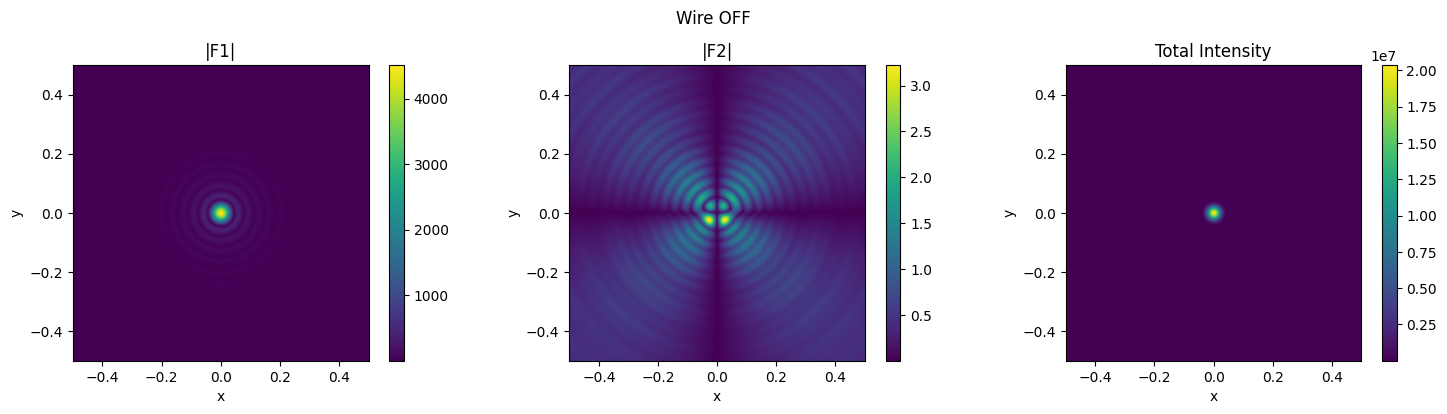

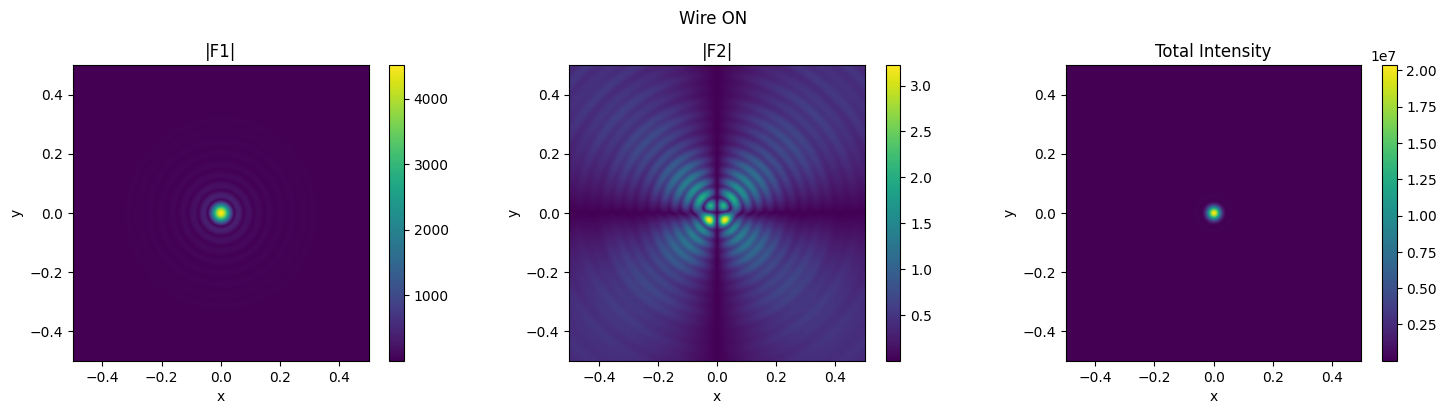

In [15]:
# Load both
x_off, y_off, F1_off, F2_off = load_grasp_grd(data_dir + "azel_1deg_off.grd")
x_on,  y_on,  F1_on,  F2_on  = load_grasp_grd(data_dir + "azel_1deg_on.grd")

# Plot
plot_beam(x_off, y_off, F1_off, F2_off, title="Wire OFF")
plot_beam(x_on,  y_on,  F1_on,  F2_on,  title="Wire ON")


In [16]:
def compute_stokes(F1, F2):
    """
    Compute Stokes parameters from two complex field components
    in a linear polarization basis.

    Parameters
    ----------
    F1, F2 : 2D complex ndarray
        Complex field components on the same grid.

    Returns
    -------
    I, Q, U, V : 2D float ndarray
        Stokes parameter maps.
    """
    E1E1 = np.abs(F1)**2
    E2E2 = np.abs(F2)**2
    cross = F1 * np.conj(F2)

    I = E1E1 + E2E2
    Q = E1E1 - E2E2
    U = 2.0 * np.real(cross)
    V = -2.0 * np.imag(cross)

    return I, Q, U, V


def plot_stokes(x, y, I, Q, U, V=None, title="Stokes Maps", use_symlog=False):
    """
    Plot Stokes parameter maps for initial inspection.

    Parameters
    ----------
    x, y : 1D ndarray
        Coordinate axes.
    I, Q, U : 2D ndarray
        Stokes maps.
    V : 2D ndarray or None
        Optional V map.
    title : str
        Overall figure title.
    use_symlog : bool
        If True, show Q/U/V with symmetric log scaling by plotting
        sign(data)*log10(1+abs(data)). Useful if dynamic range is large.
    """
    maps = [I, Q, U] if V is None else [I, Q, U, V]
    names = ["I", "Q", "U"] if V is None else ["I", "Q", "U", "V"]

    ncols = len(maps)
    fig, axs = plt.subplots(1, ncols, figsize=(5 * ncols, 4))

    if ncols == 1:
        axs = [axs]

    extent = [x.min(), x.max(), y.min(), y.max()]

    for ax, data, name in zip(axs, maps, names):
        display_data = data.copy()

        if use_symlog and name != "I":
            display_data = np.sign(data) * np.log10(1.0 + np.abs(data))

        im = ax.imshow(display_data, extent=extent, origin="lower", aspect="equal")
        ax.set_title(name if not use_symlog or name == "I" else f"{name} (signed log)")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def summarize_stokes(I, Q, U, V=None, label="dataset"):
    """
    Print a few quick summary stats for sanity checking.
    """
    print(f"\n--- {label} ---")
    print(f"I: min={I.min():.6e}, max={I.max():.6e}")
    print(f"Q: min={Q.min():.6e}, max={Q.max():.6e}")
    print(f"U: min={U.min():.6e}, max={U.max():.6e}")
    if V is not None:
        print(f"V: min={V.min():.6e}, max={V.max():.6e}")

    frac_pol = np.sqrt(Q**2 + U**2) / np.maximum(I, 1e-30)
    print(f"sqrt(Q^2+U^2)/I: min={frac_pol.min():.6e}, max={frac_pol.max():.6e}")



--- Wire OFF ---
I: min=1.688110e+00, max=2.037000e+07
Q: min=1.281158e+00, max=2.037000e+07
U: min=-3.263517e+03, max=3.263600e+03
V: min=-1.210117e+04, max=1.210119e+04
sqrt(Q^2+U^2)/I: min=9.249296e-01, max=1.000000e+00

--- Wire ON ---
I: min=1.688094e+00, max=2.036998e+07
Q: min=1.281142e+00, max=2.036998e+07
U: min=-3.255211e+03, max=3.255294e+03
V: min=-1.210397e+04, max=1.210399e+04
sqrt(Q^2+U^2)/I: min=9.251315e-01, max=1.000000e+00


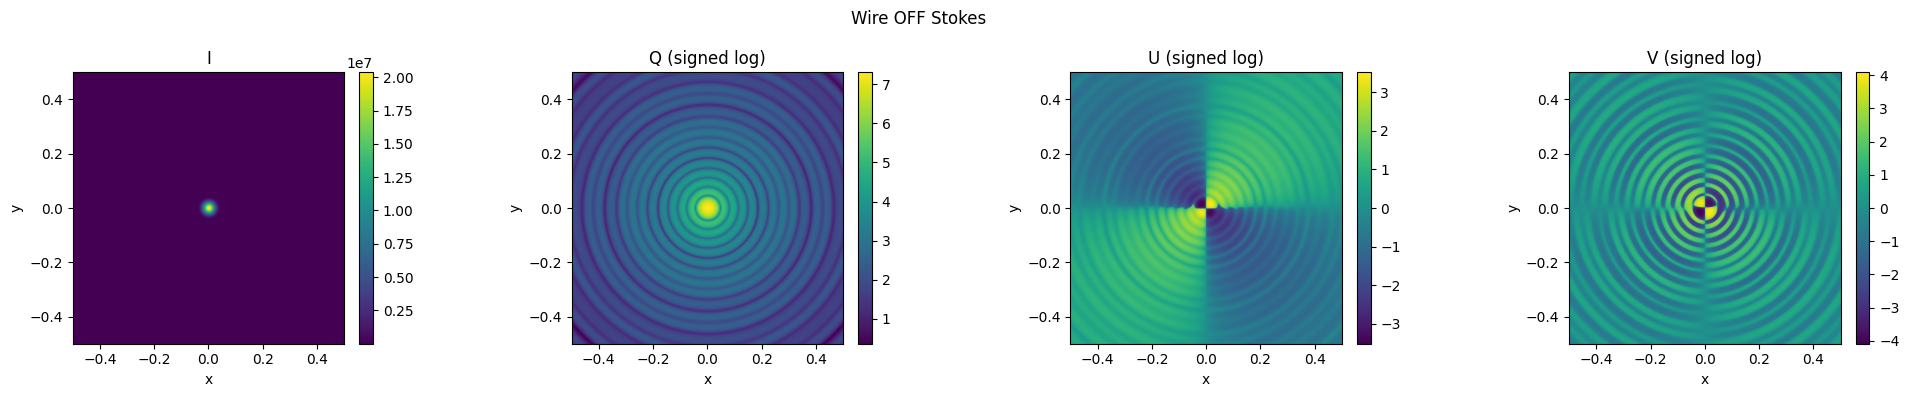

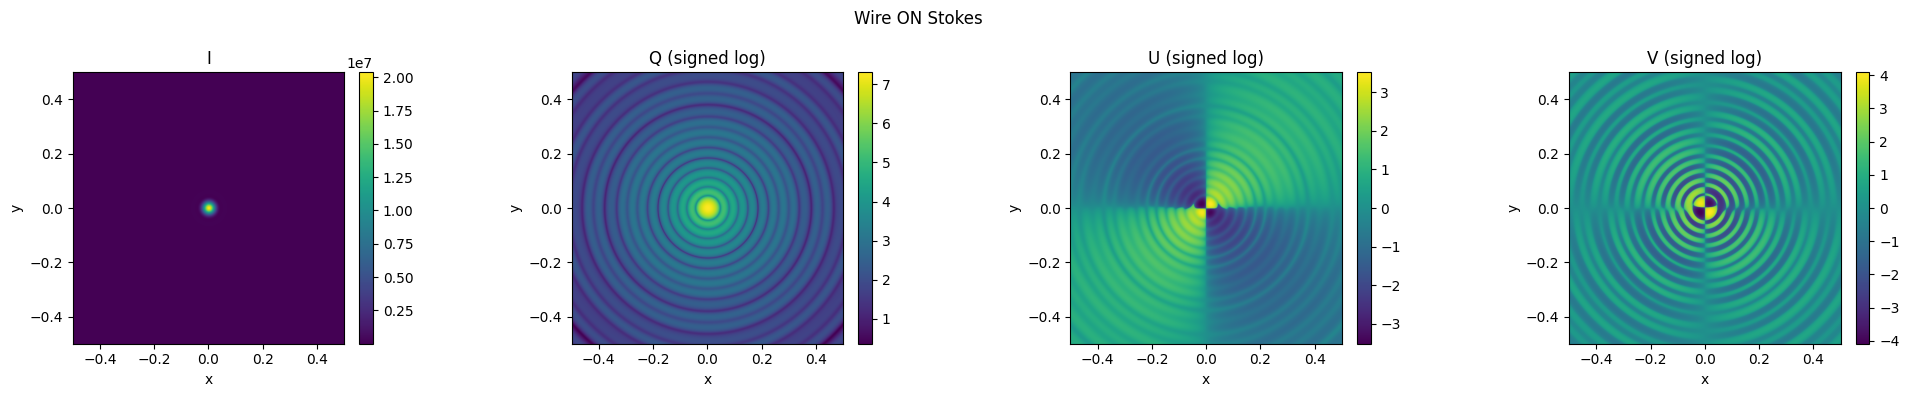

In [17]:
# Compute Stokes for wire OFF
I_off, Q_off, U_off, V_off = compute_stokes(F1_off, F2_off)

# Compute Stokes for wire ON
I_on, Q_on, U_on, V_on = compute_stokes(F1_on, F2_on)

# Quick summaries
summarize_stokes(I_off, Q_off, U_off, V_off, label="Wire OFF")
summarize_stokes(I_on, Q_on, U_on, V_on, label="Wire ON")

# Initial plots
plot_stokes(x_off, y_off, I_off, Q_off, U_off, V_off, title="Wire OFF Stokes", use_symlog=True)
plot_stokes(x_on, y_on, I_on, Q_on, U_on, V_on, title="Wire ON Stokes", use_symlog=True)


In [18]:

def compute_polarization_angle(Q, U, I=None, pol_fraction_floor=None, I_floor=None, degrees=True):
    """
    Compute linear polarization angle from Stokes Q and U.

    Uses the correct convention:
        psi = 0.5 * atan2(U, Q)

    Parameters
    ----------
    Q, U : 2D ndarray
        Stokes Q and U maps.
    I : 2D ndarray or None
        Optional Stokes I map, used for masking if desired.
    pol_fraction_floor : float or None
        If set, mask pixels where sqrt(Q^2 + U^2)/I < pol_fraction_floor.
        Requires I.
    I_floor : float or None
        If set, mask pixels where I < I_floor.
    degrees : bool
        If True, return angle in degrees. Otherwise radians.

    Returns
    -------
    psi : 2D ndarray
        Polarization angle map, with masked/invalid pixels set to NaN.
    """
    psi = 0.5 * np.arctan2(U, Q)

    mask = np.zeros(Q.shape, dtype=bool)

    if I_floor is not None:
        if I is None:
            raise ValueError("I must be provided if using I_floor.")
        mask |= (I < I_floor)

    if pol_fraction_floor is not None:
        if I is None:
            raise ValueError("I must be provided if using pol_fraction_floor.")
        p_lin = np.sqrt(Q**2 + U**2)
        frac_pol = p_lin / np.maximum(I, 1e-30)
        mask |= (frac_pol < pol_fraction_floor)

    psi = np.where(mask, np.nan, psi)

    if degrees:
        psi = np.degrees(psi)

    return psi


def plot_polarization_angle(x, y, psi, title="Polarization Angle", cmap="twilight"):
    """
    Plot polarization angle map.
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(
        psi,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap=cmap
    )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, label="Angle [deg]")
    plt.tight_layout()
    plt.show()


def summarize_polarization_angle(psi, label="dataset"):
    """
    Print quick summary stats for polarization angle map, ignoring NaNs.
    """
    valid = np.isfinite(psi)
    if not np.any(valid):
        print(f"\n--- {label} ---")
        print("No valid pixels in polarization angle map.")
        return

    vals = psi[valid]
    print(f"\n--- {label} polarization angle ---")
    print(f"valid pixels: {valid.sum()} / {valid.size}")
    print(f"min = {np.nanmin(vals):.6f} deg")
    print(f"max = {np.nanmax(vals):.6f} deg")
    print(f"mean = {np.nanmean(vals):.6f} deg")
    print(f"std = {np.nanstd(vals):.6f} deg")




--- Wire OFF polarization angle ---
valid pixels: 24221 / 1002001
min = -0.433347 deg
max = 0.433344 deg
mean = 0.000000 deg
std = 0.130415 deg

--- Wire ON polarization angle ---
valid pixels: 24221 / 1002001
min = -0.432329 deg
max = 0.432326 deg
mean = 0.000000 deg
std = 0.130369 deg


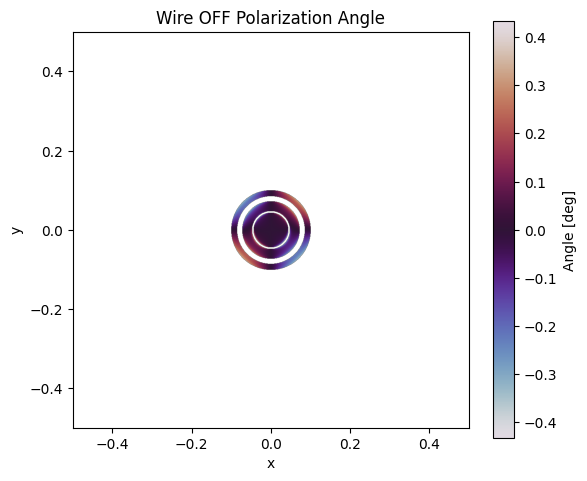

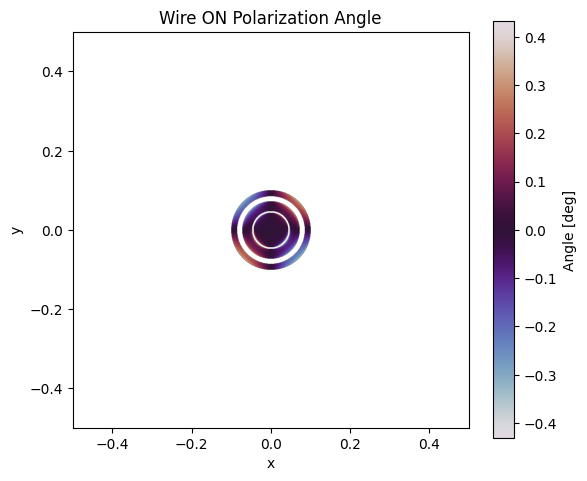

In [26]:

# Example intensity thresholds: keep only reasonably bright parts of the beam
I_floor_off = 1e-3 * np.nanmax(I_off) * 1
I_floor_on  = 1e-3 * np.nanmax(I_on)  * 1

psi_off = compute_polarization_angle(Q_off, U_off, I=I_off, I_floor=I_floor_off, degrees=True)
psi_on  = compute_polarization_angle(Q_on,  U_on,  I=I_on,  I_floor=I_floor_on,  degrees=True)

summarize_polarization_angle(psi_off, label="Wire OFF")
summarize_polarization_angle(psi_on,  label="Wire ON")

plot_polarization_angle(x_off, y_off, psi_off, title="Wire OFF Polarization Angle")
plot_polarization_angle(x_on,  y_on,  psi_on,  title="Wire ON Polarization Angle")



--- Wire OFF polarization angle ---
valid pixels: 1002001 / 1002001
min = -19.264437 deg
max = 19.264122 deg
mean = -0.000001 deg
std = 2.565494 deg

--- Wire ON polarization angle ---
valid pixels: 1002001 / 1002001
min = -19.269490 deg
max = 19.269312 deg
mean = -0.000000 deg
std = 2.565641 deg


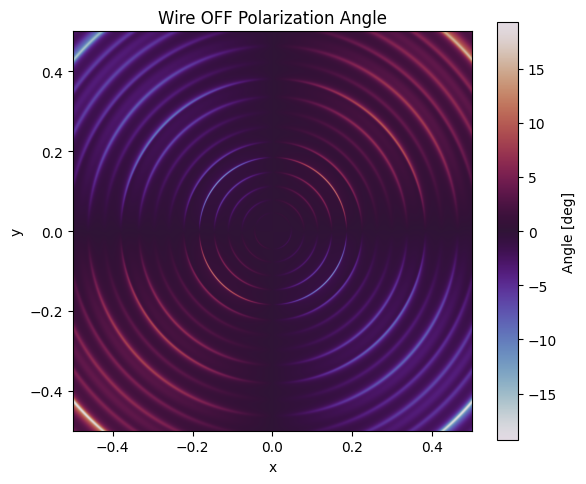

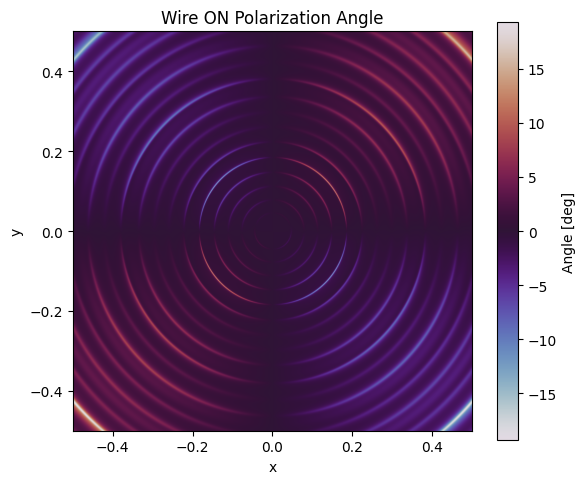

In [28]:

# Example intensity thresholds: keep only reasonably bright parts of the beam
I_floor_off = 1e-3 * np.nanmax(I_off)
I_floor_on  = 1e-3 * np.nanmax(I_on)

psi_off = compute_polarization_angle(Q_off, U_off, I=I_off, degrees=True)
psi_on  = compute_polarization_angle(Q_on,  U_on,  I=I_on, degrees=True)

summarize_polarization_angle(psi_off, label="Wire OFF")
summarize_polarization_angle(psi_on,  label="Wire ON")

plot_polarization_angle(x_off, y_off, psi_off, title="Wire OFF Polarization Angle")
plot_polarization_angle(x_on,  y_on,  psi_on,  title="Wire ON Polarization Angle")


In [30]:
def wrap_linear_pol_angle_deg(angle_deg):
    """
    Wrap a linear polarization angle into [-90, 90) degrees.
    """
    return ((angle_deg + 90.0) % 180.0) - 90.0


def polarization_angle_difference_deg(psi_on_deg, psi_off_deg):
    """
    Compute the difference between two linear polarization angle maps
    in degrees, correctly handling the 180-degree ambiguity.

    Returns delta_psi in [-90, 90) degrees.
    """
    # Work in doubled-angle space to respect linear polarization symmetry
    two_on = np.radians(2.0 * psi_on_deg)
    two_off = np.radians(2.0 * psi_off_deg)

    # Wrapped difference in doubled-angle space
    delta_two = np.arctan2(np.sin(two_on - two_off), np.cos(two_on - two_off))

    # Convert back to ordinary linear polarization angle difference
    delta_psi_deg = np.degrees(0.5 * delta_two)

    return delta_psi_deg


def plot_angle_difference(x, y, delta_psi_deg, title=r"$\psi_{\rm on} - \psi_{\rm off}$", cmap="coolwarm",
                          vmin=None, vmax=None):
    """
    Plot polarization angle difference map.
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    if vmin is None or vmax is None:
        finite = np.isfinite(delta_psi_deg)
        if np.any(finite):
            lim = np.nanmax(np.abs(delta_psi_deg[finite]))
            vmin = -lim
            vmax = lim
        else:
            vmin, vmax = -1, 1

    im = ax.imshow(
        delta_psi_deg,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin="lower",
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.colorbar(im, ax=ax, label=r"$\Delta \psi$ [deg]")
    plt.tight_layout()
    plt.show()


def summarize_angle_difference(delta_psi_deg, label="delta psi"):
    """
    Print summary statistics for an angle-difference map, ignoring NaNs.
    """
    finite = np.isfinite(delta_psi_deg)
    if not np.any(finite):
        print(f"\n--- {label} ---")
        print("No valid pixels.")
        return

    vals = delta_psi_deg[finite]
    print(f"\n--- {label} ---")
    print(f"valid pixels: {finite.sum()} / {finite.size}")
    print(f"min  = {np.nanmin(vals):.6f} deg")
    print(f"max  = {np.nanmax(vals):.6f} deg")
    print(f"mean = {np.nanmean(vals):.6f} deg")
    print(f"std  = {np.nanstd(vals):.6f} deg")


--- Wire ON - OFF angle difference ---
valid pixels: 1002001 / 1002001
min  = -0.011294 deg
max  = 0.011402 deg
mean = 0.000000 deg
std  = 0.001733 deg


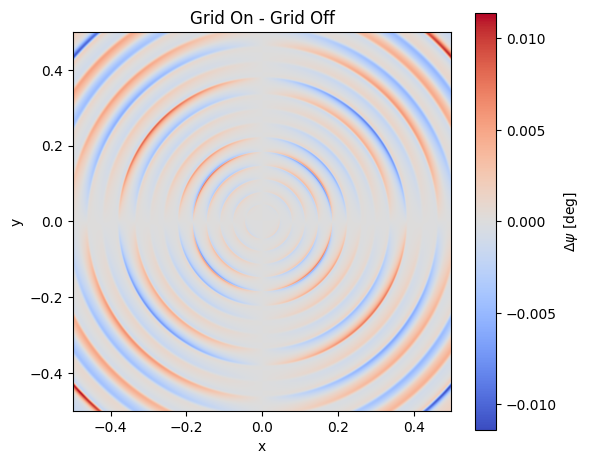

In [32]:
delta_psi = polarization_angle_difference_deg(psi_on, psi_off)

summarize_angle_difference(delta_psi, label="Wire ON - OFF angle difference")
plot_angle_difference(x_on, y_on, delta_psi, title=r"Grid On - Grid Off")
